In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier

In [5]:
data_path = "../data/cleaned_facilities.csv"

df = pd.read_csv(data_path)

df.head()

,facility_id,location,facility_type,cleanliness_score,odor_score,waste_level,water_availability,footfall,complaints,inspection_date,hours_since_cleaning,hygiene_risk
0,F0001,Nagpur Central,Public Washroom,6.1,4.7,45.5,Yes,584,5,2026-08-05,8.5,Medium
1,F0002,Sadar,School Washroom,5.9,5.9,54.6,Yes,106,4,2026-08-03,9.1,Medium
2,F0003,Dharampeth,Public Washroom,3.5,6.2,95.8,Yes,446,9,2026-06-22,3.1,High
3,F0004,Hingna,Public Washroom,10.0,1.0,21.0,Yes,424,1,2026-03-05,4.6,Low
4,F0005,Dharampeth,Office Washroom,3.0,7.2,54.5,Yes,133,7,2026-05-29,9.1,High


In [6]:
print("Dataset Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nMissing Values:")
print(df.isnull().sum())

Dataset Shape: (995, 12)

Columns:
['facility_id', 'location', 'facility_type', 'cleanliness_score', 'odor_score', 'waste_level', 'water_availability', 'footfall', 'complaints', 'inspection_date', 'hours_since_cleaning', 'hygiene_risk']

Missing Values:
facility_id             0
location                0
facility_type           0
cleanliness_score       0
odor_score              0
waste_level             3
water_availability      2
footfall                0
complaints              0
inspection_date         0
hours_since_cleaning    0
hygiene_risk            0
dtype: int64


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 995 entries, 0 to 994
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   facility_id           995 non-null    str    
 1   location              995 non-null    str    
 2   facility_type         995 non-null    str    
 3   cleanliness_score     995 non-null    float64
 4   odor_score            995 non-null    float64
 5   waste_level           992 non-null    float64
 6   water_availability    993 non-null    str    
 7   footfall              995 non-null    int64  
 8   complaints            995 non-null    int64  
 9   inspection_date       995 non-null    str    
 10  hours_since_cleaning  995 non-null    float64
 11  hygiene_risk          995 non-null    str    
dtypes: float64(4), int64(2), str(6)
memory usage: 93.4 KB


In [8]:
df.describe()

,cleanliness_score,odor_score,waste_level,footfall,complaints,hours_since_cleaning
count,995.000000,995.000000,992.000000,995.000000,995.000000,995.000000
mean,6.422211,4.634573,43.989113,441.834171,4.485427,7.603116
std,1.731911,2.037992,20.604954,205.356635,2.459846,7.263468
min,1.100000,1.000000,0.000000,20.000000,0.000000,0.500000
25%,5.200000,3.100000,29.100000,304.000000,3.000000,2.500000
50%,6.400000,4.600000,44.000000,435.000000,4.000000,5.300000
75%,7.600000,6.100000,58.725000,581.000000,6.000000,10.200000
max,10.000000,10.000000,100.000000,1148.000000,12.000000,36.000000


hygiene_risk
Medium    410
Low       313
High      272
Name: count, dtype: int64


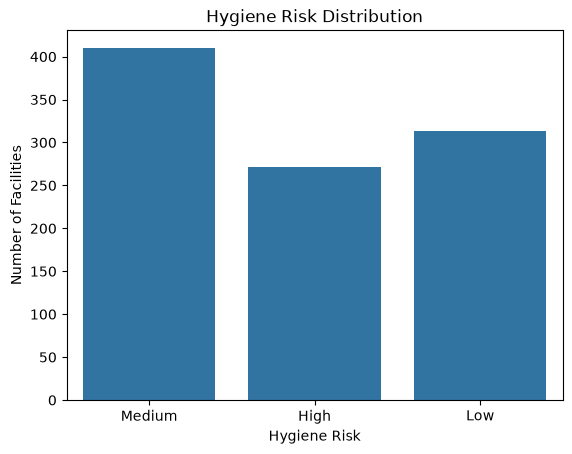

In [9]:
print(df["hygiene_risk"].value_counts())

sns.countplot(data=df, x="hygiene_risk")
plt.title("Hygiene Risk Distribution")
plt.xlabel("Hygiene Risk")
plt.ylabel("Number of Facilities")
plt.show()

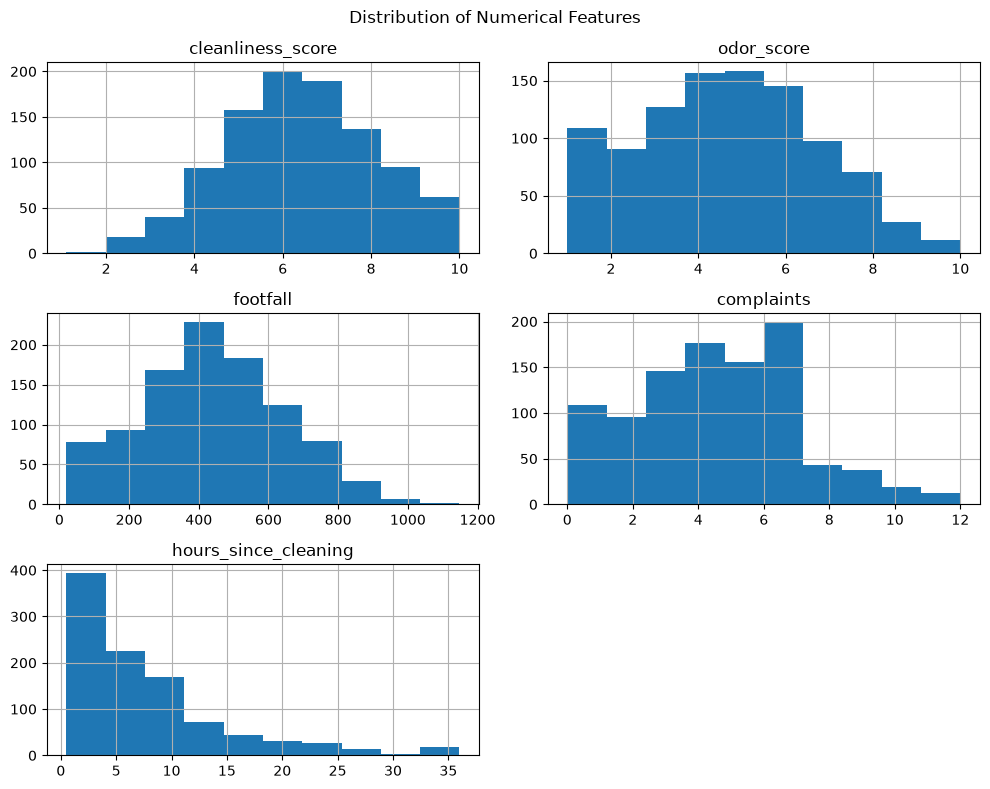

In [10]:
numeric_columns = [
    "cleanliness_score",
    "odor_score",
    "footfall",
    "complaints",
    "hours_since_cleaning"
]

df[numeric_columns].hist(figsize=(10, 8))
plt.suptitle("Distribution of Numerical Features")
plt.tight_layout()
plt.show()

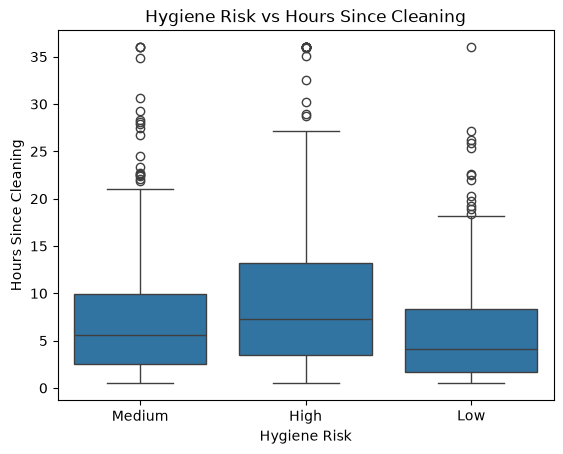

In [11]:
sns.boxplot(data=df, x="hygiene_risk", y="hours_since_cleaning")
plt.title("Hygiene Risk vs Hours Since Cleaning")
plt.xlabel("Hygiene Risk")
plt.ylabel("Hours Since Cleaning")
plt.show()

In [12]:
df["waste_level"] = df["waste_level"].fillna(df["waste_level"].median())
df["water_availability"] = df["water_availability"].fillna(df["water_availability"].mode()[0])

print("Missing values after preprocessing:")
print(df.isnull().sum())

Missing values after preprocessing:
facility_id             0
location                0
facility_type           0
cleanliness_score       0
odor_score              0
waste_level             0
water_availability      0
footfall                0
complaints              0
inspection_date         0
hours_since_cleaning    0
hygiene_risk            0
dtype: int64


In [13]:
df["complaints_per_100_footfall"] = (
    df["complaints"] / df["footfall"]
) * 100

df[["complaints", "footfall", "complaints_per_100_footfall"]].head()

,complaints,footfall,complaints_per_100_footfall
0,5,584,0.856164
1,4,106,3.773585
2,9,446,2.017937
3,1,424,0.235849
4,7,133,5.263158


In [15]:
label_encoders = {}

categorical_columns = [
    "location",
    "facility_type",
    "water_availability"
]

for column in categorical_columns:
    encoder = LabelEncoder()
    df[column] = encoder.fit_transform(df[column])
    label_encoders[column] = encoder

In [16]:
target_encoder = LabelEncoder()

df["hygiene_risk"] = target_encoder.fit_transform(df["hygiene_risk"])

print("Target classes:", target_encoder.classes_)

Target classes: ['High' 'Low' 'Medium']


In [17]:
features = [
    "location",
    "facility_type",
    "cleanliness_score",
    "odor_score",
    "waste_level",
    "water_availability",
    "footfall",
    "complaints",
    "hours_since_cleaning",
    "complaints_per_100_footfall"
]

X = df[features]
y = df["hygiene_risk"]

print("Features:", X.columns.tolist())
print("X shape:", X.shape)
print("y shape:", y.shape)

Features: ['location', 'facility_type', 'cleanliness_score', 'odor_score', 'waste_level', 'water_availability', 'footfall', 'complaints', 'hours_since_cleaning', 'complaints_per_100_footfall']
X shape: (995, 10)
y shape: (995,)


In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 796
Testing samples: 199


In [19]:
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

print("Model training completed.")

Model training completed.


In [20]:
y_pred = model.predict(X_test)

print("Predictions completed.")

Predictions completed.


In [21]:
accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", accuracy)
print("Accuracy Percentage:", round(accuracy * 100, 2), "%")

Model Accuracy: 0.8793969849246231
Accuracy Percentage: 87.94 %


In [22]:
print("Classification Report:")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=target_encoder.classes_
    )
)

Classification Report:
              precision    recall  f1-score   support

        High       0.94      0.87      0.90        54
         Low       0.93      0.84      0.88        63
      Medium       0.82      0.91      0.86        82

    accuracy                           0.88       199
   macro avg       0.90      0.88      0.88       199
weighted avg       0.89      0.88      0.88       199



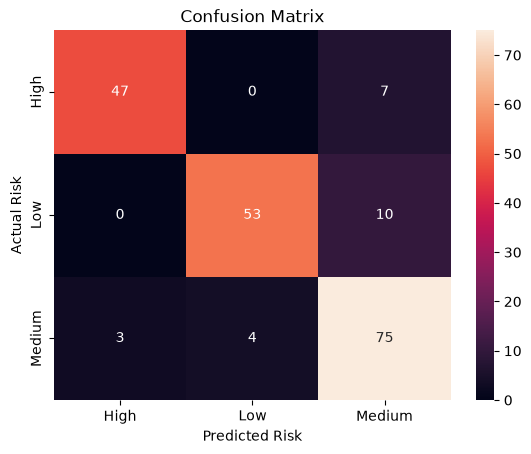

In [23]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=target_encoder.classes_,
    yticklabels=target_encoder.classes_
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Risk")
plt.ylabel("Actual Risk")
plt.show()

In [24]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
}).sort_values(by="Importance", ascending=False)

print(feature_importance)

                       Feature  Importance
2            cleanliness_score    0.277311
3                   odor_score    0.174178
7                   complaints    0.154236
4                  waste_level    0.133404
8         hours_since_cleaning    0.082779
9  complaints_per_100_footfall    0.061550
6                     footfall    0.042143
5           water_availability    0.036927
0                     location    0.021205
1                facility_type    0.016267


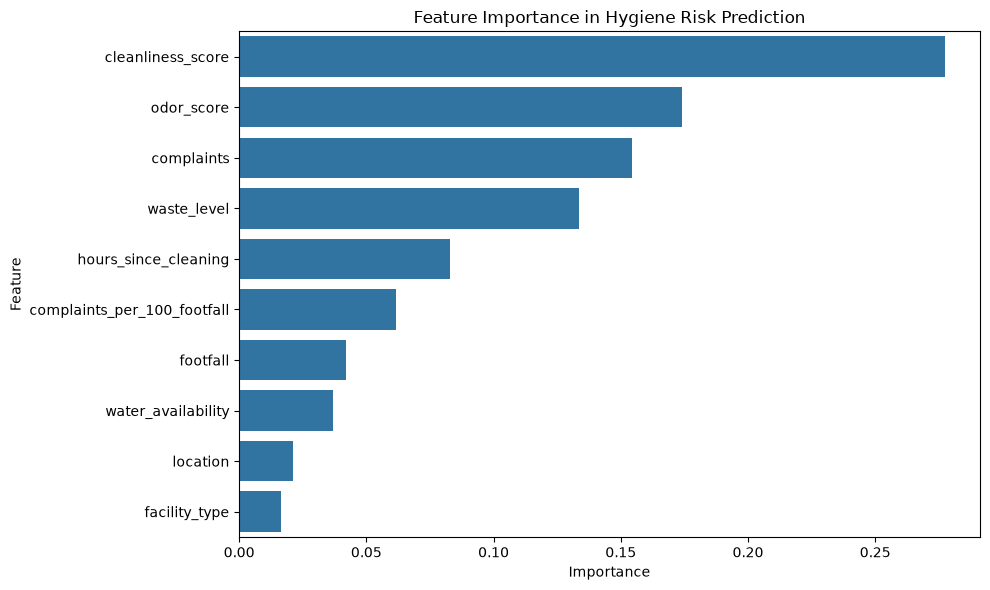

In [25]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Feature"
)

plt.title("Feature Importance in Hygiene Risk Prediction")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

In [26]:
new_facility = pd.DataFrame({
    "location": [X["location"].mode()[0]],
    "facility_type": [X["facility_type"].mode()[0]],
    "cleanliness_score": [5.0],
    "odor_score": [6.0],
    "waste_level": [60.0],
    "water_availability": [X["water_availability"].mode()[0]],
    "footfall": [500],
    "complaints": [7],
    "hours_since_cleaning": [12.0],
    "complaints_per_100_footfall": [(7 / 500) * 100]
})

predicted_risk = model.predict(new_facility)

predicted_risk_label = target_encoder.inverse_transform(predicted_risk)

print("Predicted Hygiene Risk:", predicted_risk_label[0])

Predicted Hygiene Risk: High


In [27]:
def predict_hygiene_risk(facility_data):
    try:
        prediction = model.predict(facility_data)
        return target_encoder.inverse_transform(prediction)[0]
    except Exception as error:
        return f"Prediction Error: {error}"

In [28]:
result = predict_hygiene_risk(new_facility)

print("Test Prediction:", result)

Test Prediction: High


In [29]:
assert len(y_test) == len(y_pred)
assert accuracy >= 0.70

print("All basic model tests passed.")

All basic model tests passed.


In [30]:
import joblib

joblib.dump(model, "../models/hygiene_risk_model.pkl")
joblib.dump(target_encoder, "../models/target_encoder.pkl")

print("Model and encoder saved successfully.")

Model and encoder saved successfully.


In [31]:
joblib.dump(label_encoders, "../models/feature_encoders.pkl")

print("Feature encoders saved successfully.")

Feature encoders saved successfully.
